In [1]:
from pathlib import Path
import rasterio
import pandas as pd
import numpy as np
from pyproj import Transformer

raster_path = "../data/raw/LF2025_FBFM40_CONUS.tif"

df = pd.read_csv(
    "../data/interim/calfire.csv"
)

fires = df[df["incident_latitude"].between(32, 50) & df["incident_longitude"].between(-125, -114)].copy()

# Parse the date
fires["incident_date_created"] = pd.to_datetime(
    fires["incident_date_created"],
    errors="coerce"
)

# Extract year
fires["incident_year"] = fires["incident_date_created"].dt.year

# Remove missing dates and fires before 2013
fires = fires[
    fires["incident_year"].notna()
    & fires["incident_year"].ge(2013)
].copy()

fires["incident_year"] = fires["incident_year"].astype(int)

In [2]:
import numpy as np

available_landfire_years = np.array([
    2016,
    2022,
    2023,
    2024,
    2025
])

def assign_landfire_year(fire_year):
    prior_years = available_landfire_years[
        available_landfire_years <= fire_year
    ]

    if len(prior_years) == 0:
        return np.nan

    return prior_years.max()

In [3]:
fires["landfire_year"] = (
    fires["incident_year"]
    .apply(assign_landfire_year)
    .astype("Int64")
)

In [4]:
fires.columns

Index(['incident_name', 'incident_is_final', 'incident_date_last_update',
       'incident_date_created', 'incident_administrative_unit',
       'incident_administrative_unit_url', 'incident_county',
       'incident_location', 'incident_acres_burned', 'incident_containment',
       'incident_control', 'incident_cooperating_agencies',
       'incident_longitude', 'incident_latitude', 'incident_type',
       'incident_id', 'incident_url', 'incident_date_extinguished',
       'incident_dateonly_extinguished', 'incident_dateonly_created',
       'is_active', 'calfire_incident', 'notification_desired', 'end_date',
       'diff_days', 'bin_fire_days', 'incident_year', 'landfire_year'],
      dtype='str')

In [5]:
raw_folder = Path(
    "/Users/qingwong/MIDS-207-project/data/raw"
)

year_col = "landfire_year"
lat_col = "incident_latitude"
lon_col = "incident_longitude"

# Map each LANDFIRE year to the files you currently have
landfire_files = {
    2016: {
        "system": "FBFM40",
        "raster": raw_folder / "LF2016_FBFM40_CONUS.tif",
        "lookup": raw_folder / "LF2016_FBFM40.csv",
    },
    2022: {
        "system": "FBFM40",
        "raster": raw_folder / "LF2022_FBFM40_CONUS.tif",
        "lookup": raw_folder / "LF2022_FBFM40.csv",
    },
    2023: {
        "system": "FBFM40",
        "raster": raw_folder / "LF2023_FBFM40_CONUS.tif",
        "lookup": raw_folder / "LF2023_FBFM40.csv",
    },
    2024: {
        "system": "FBFM40",
        "raster": raw_folder / "LF2024_FBFM40_CONUS.tif",
        "lookup": raw_folder / "LF2024_FBFM40.csv",
    },
    2025: {
        "system": "FBFM40",
        "raster": raw_folder / "LF2025_FBFM40_CONUS.tif",
        "lookup": raw_folder / "LF2025_FBFM40.csv",
    },
}

In [6]:
fires["fuel_fbfm40_value"] = np.nan
fires["fuel_fbfm40_code"] = pd.NA


In [7]:
for landfire_year in sorted(fires[year_col].dropna().unique()):

    landfire_year = int(landfire_year)
    year_mask = fires[year_col].eq(landfire_year)
    raster_path = landfire_files[landfire_year]["raster"]
    lookup_path = landfire_files[landfire_year]["lookup"]
    fuel_lookup = pd.read_csv(
        lookup_path,
        usecols=["VALUE", "FBFM40"]
    )

    fuel_code_map = (
        fuel_lookup
        .drop_duplicates("VALUE")
        .set_index("VALUE")["FBFM40"]
        .to_dict()
    )

    with rasterio.open(raster_path) as src:

        print(
            f"Sampling {landfire_year}: "
            f"{year_mask.sum()} incidents"
        )
        print("CRS:", src.crs)
        print("Resolution:", src.res)
        print("NoData:", src.nodata)

        transformer = Transformer.from_crs(
            "EPSG:4326",
            src.crs,
            always_xy=True
        )

        raster_coords = [
            transformer.transform(lon, lat)
            for lon, lat in zip(
                fires.loc[year_mask, lon_col],
                fires.loc[year_mask, lat_col]
            )
        ]

        sampled = np.array([
            value[0]
            for value in src.sample(raster_coords)
        ]).astype(float)

        if src.nodata is not None:
            sampled[sampled == src.nodata] = np.nan

    sampled_codes = (
        pd.Series(sampled)
        .map(fuel_code_map)
        .to_numpy()
    )

    fires.loc[
        year_mask,
        "fuel_fbfm40_value"
    ] = sampled

    fires.loc[
        year_mask,
        "fuel_fbfm40_code"
    ] = sampled_codes

Sampling 2016: 1586 incidents
CRS: EPSG:5070
Resolution: (30.0, 30.0)
NoData: 32767.0
Sampling 2022: 150 incidents
CRS: EPSG:5070
Resolution: (30.0, 30.0)
NoData: 32767.0
Sampling 2023: 133 incidents
CRS: EPSG:5070
Resolution: (30.0, 30.0)
NoData: 32767.0
Sampling 2024: 612 incidents
CRS: EPSG:5070
Resolution: (30.0, 30.0)
NoData: 32767.0
Sampling 2025: 700 incidents
CRS: EPSG:5070
Resolution: (30.0, 30.0)
NoData: 32767.0


In [8]:
year_col = "landfire_year"
lat_col = "incident_latitude"
lon_col = "incident_longitude"

with rasterio.open(raster_path) as src:

    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)

    transformer = Transformer.from_crs(
        "EPSG:4326",
        src.crs,
        always_xy=True
    )

    raster_coords = [
        transformer.transform(lon, lat)
        for lon, lat in zip(
            fires[lon_col],
            fires[lat_col]
        )
    ]

    sampled = np.array([
        value[0]
        for value in src.sample(raster_coords)
    ]).astype(float)

    if src.nodata is not None:
        sampled[sampled == src.nodata] = np.nan

fires["fuel_fbfm40_value"] = sampled

fuel_code_map = (
    fuel_lookup
    .set_index("VALUE")["FBFM40"]
    .to_dict()
)

fires["fuel_fbfm40_code"] = (
    fires["fuel_fbfm40_value"]
    .map(fuel_code_map)
)

fires[
    [
        "incident_name",
        lat_col,
        lon_col,
        "fuel_fbfm40_value",
        "fuel_fbfm40_code"
    ]
].head(20)

CRS: EPSG:5070
Resolution: (30.0, 30.0)
NoData: 32767.0


,incident_name,incident_latitude,incident_longitude,fuel_fbfm40_value,fuel_fbfm40_code
0,Bridge Fire,40.774000,-122.309000,165.0,TU5
2,River Fire,36.602575,-118.016510,102.0,GR2
3,Fawnskin Fire,34.288877,-116.941311,165.0,TU5
4,Gold Fire,37.116295,-119.635004,144.0,SH4
5,Panther Fire,40.190062,-121.595555,185.0,TL5
6,Silverado Fire,38.441792,-122.350844,91.0,NB1
7,Yellow Fire,38.638828,-122.655616,123.0,GS3
8,Summit Fire,34.288877,-116.941311,165.0,TU5
9,Tres Pinos Fire,37.160346,-120.937494,102.0,GR2
10,306 Fire,39.514139,-122.560862,145.0,SH5


In [9]:
fires[
    [
        "incident_name",
        year_col,
        lat_col,
        lon_col,
        "fuel_fbfm40_value",
        "fuel_fbfm40_code"
    ]
].head(20)

,incident_name,landfire_year,incident_latitude,incident_longitude,fuel_fbfm40_value,fuel_fbfm40_code
0,Bridge Fire,2016,40.774000,-122.309000,165.0,TU5
2,River Fire,<NA>,36.602575,-118.016510,102.0,GR2
3,Fawnskin Fire,<NA>,34.288877,-116.941311,165.0,TU5
4,Gold Fire,<NA>,37.116295,-119.635004,144.0,SH4
5,Panther Fire,<NA>,40.190062,-121.595555,185.0,TL5
6,Silverado Fire,<NA>,38.441792,-122.350844,91.0,NB1
7,Yellow Fire,<NA>,38.638828,-122.655616,123.0,GS3
8,Summit Fire,<NA>,34.288877,-116.941311,165.0,TU5
9,Tres Pinos Fire,<NA>,37.160346,-120.937494,102.0,GR2
10,306 Fire,<NA>,39.514139,-122.560862,145.0,SH5


In [10]:
fires['fuel_fbfm40_code'].value_counts()

fuel_fbfm40_code
NB1    1324
GR2     586
GS2     409
GS1     167
GR1     142
TU5     121
SH4     108
SH5     106
SH2      88
NB9      75
TL3      47
SH1      37
TU2      35
NB3      29
TL8      27
GR3      26
TL6      25
TL5      18
GS3      18
NB8      18
TL1      16
TL4      16
TU3      13
TU1      11
TL9       9
TL7       7
TL2       6
SH7       2
SB2       1
SH6       1
Name: count, dtype: int64

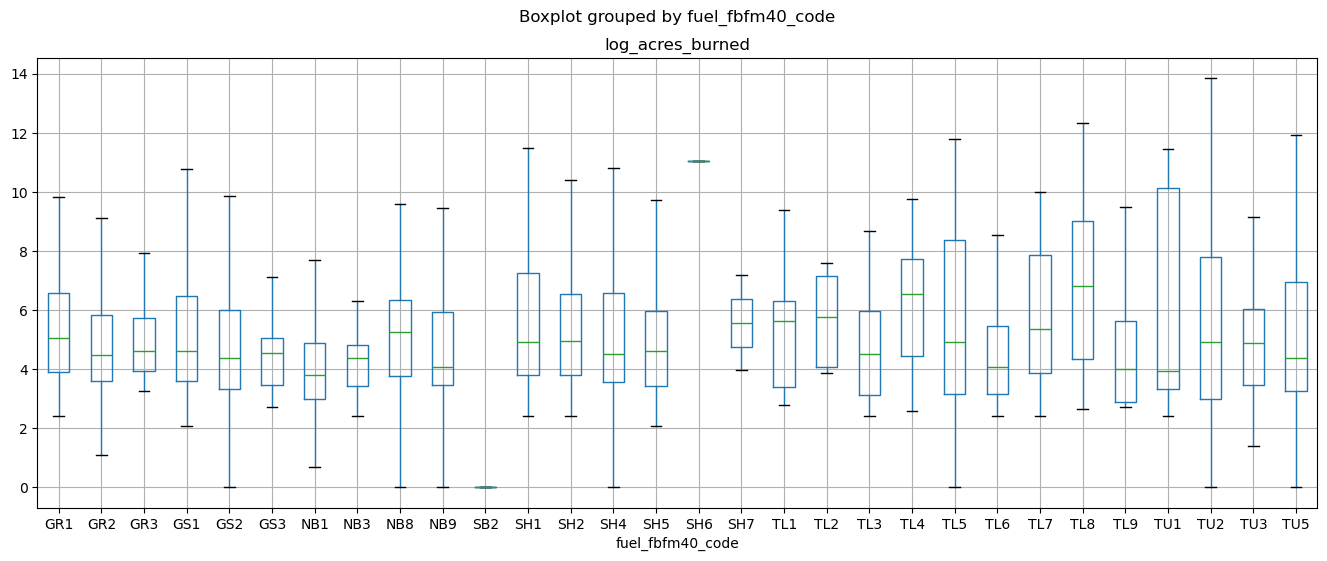

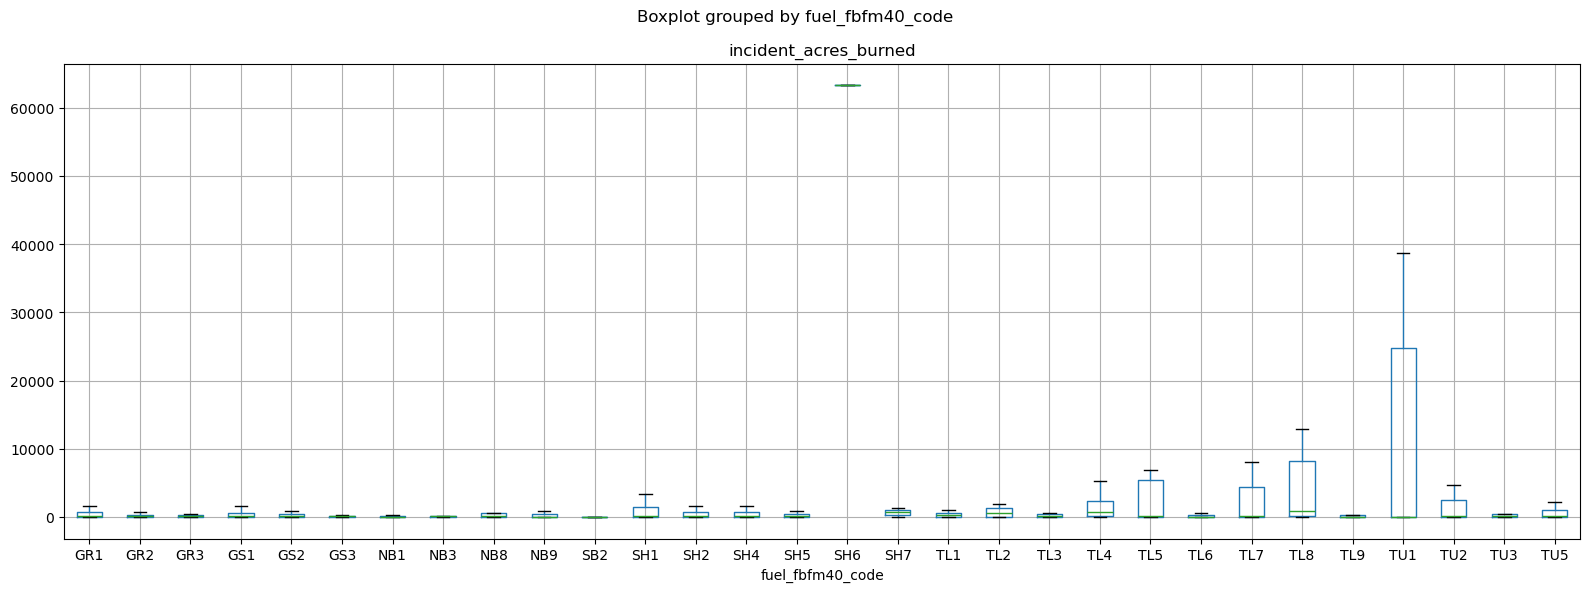

In [15]:
import matplotlib.pyplot as plt

plot_df = fires[
    ["fuel_fbfm40_code", "incident_acres_burned"]
].dropna()

plot_df['log_acres_burned'] = np.log1p(plot_df["incident_acres_burned"])

plot_df.boxplot(
    column="log_acres_burned",
    by="fuel_fbfm40_code",
    figsize=(16, 6),
    showfliers=False
)

plot_df.boxplot(
    column="incident_acres_burned",
    by="fuel_fbfm40_code",
    figsize=(16, 6),
    showfliers=False
)

# plt.yscale("log")
# plt.xlabel("FBFM40 fuel model")
# plt.ylabel("Acres burned, log scale")
# plt.title("Fire Size by FBFM40 Fuel Model")
# plt.suptitle("")
# plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [14]:
fires['incident_acres_burned'].describe()

count    3.435000e+03
mean     3.613044e+03
std      3.181628e+04
min      0.000000e+00
25%      2.500000e+01
50%      6.800000e+01
75%      2.910000e+02
max      1.032648e+06
Name: incident_acres_burned, dtype: float64

In [ ]:
#Export this

#fires.to_csv('../data/raw/calfire_fuels.csv')